# Data Management — BBO Capstone

Load weekly results from the portal, update function data, and inspect statistics.
Run this after you receive results for a given week, then use **weekly_workflow.ipynb** for the next week.

## 1. Setup

In [1]:
import sys
from pathlib import Path
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

from src.data import (
    FunctionData,
    DATA_DIR,
    load_results,
    load_latest_results,
    initialize_all_weeks,
    update_all_functions_with_results,
    update_function_with_result,
)
from src.utils import display_competition_summary, plot_progress, analyze_weekly_performance

print("✓ Imports ready")

✓ Imports ready


## 2. Load functions and historical data

In [2]:
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
num_weeks = initialize_all_weeks(functions)
print(f"✓ Loaded {len(functions)} functions with {num_weeks} weeks of history")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results
Loading weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_4
✓ Week 4: Updated 8 functions
✓ Loaded Week 5 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_5
✓ Week 5: Updated 8 functions
✓ Loaded Week 6 from /home/robin/Personal_Develo

## 3. Load new week results

After you receive results from the portal, save them into `data/results/week_N/` (create the folder if needed):
- `inputs.txt` — one list of 8 arrays (or append to existing format)
- `outputs.txt` — one list of 8 floats

Then run the cell below to load the **latest** week (or change `week_index`).

In [3]:
# Load latest week's results (or set week_index: 0=week 1, 1=week 2, -1=latest)
inputs_dict, outputs_dict, week_num = load_latest_results()
print(f"Week {week_num}: {len(inputs_dict)} functions")

✓ Loaded Week 11 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_11
Week 11: 8 functions


## 4. Update all functions with new results

In [4]:
# Update in-memory and save to data/function_N/week_W_inputs.npy and week_W_outputs.npy
update_all_functions_with_results(functions, inputs_dict, outputs_dict, week_num, save=True)

UPDATING ALL FUNCTIONS WITH WEEK 11 RESULTS

✓ Function 1 (2D): y=-0.000000, best=0.000000
    Total samples: 22

✓ Function 2 (2D): y=0.522733, best=0.620709
    Total samples: 22

✓ Function 3 (3D): y=-0.015296, best=-0.005532
    Total samples: 27

✓ Function 4 (4D): y=0.623458, best=0.667311
    Total samples: 42

✓ Function 5 (4D): y=8044.760102, best=8662.405001
    Total samples: 32

✓ Function 6 (5D): y=-0.481258, best=-0.474483
    Total samples: 32

✓ Function 7 (6D): y=3.113694, best=3.113694
    Total samples: 42

✓ Function 8 (8D): y=9.971637, best=9.971642
    Total samples: 52

✓ Updated 8 functions. New bests: 0


[{'func_id': 1,
  'n_dims': 2,
  'y': -5.4215544887950985e-101,
  'best_y': np.float64(2.6752879910742468e-09),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 22},
 {'func_id': 2,
  'n_dims': 2,
  'y': 0.522732947168383,
  'best_y': np.float64(0.6207093868270447),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 22},
 {'func_id': 3,
  'n_dims': 3,
  'y': -0.015296072400375525,
  'best_y': np.float64(-0.005531568722558512),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 27},
 {'func_id': 4,
  'n_dims': 4,
  'y': 0.6234575095217605,
  'best_y': np.float64(0.6673108763810096),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 42},
 {'func_id': 5,
  'n_dims': 4,
  'y': 8044.760102231177,
  'best_y': np.float64(8662.405001248297),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 32},
 {'func_id': 6,
  'n_dims': 5,
  'y': -0.4812580956235465,
  'best_y': np.float64(-0.4744830152863695),
  'is_new_best': np.Fal

## 5. Analyze week performance (optional)

In [5]:
analysis = analyze_weekly_performance(week_num, functions)

ANALYZING WEEK 11 PERFORMANCE
✓ Loaded Week 11 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_11
Func   Dims   Old Best     New Value    Change       Status         
--------------------------------------------------------------------------------
1      2      0.000000     -0.000000       -0.000000 ✗ Declining    
2      2      0.620709     0.522733        -0.097976 ✗ Declining    
3      3      -0.005532    -0.015296       -0.009765 ✗ Declining    
4      4      0.667311     0.623458        -0.043853 ✗ Declining    
5      4      8662.405001  8044.760102   -617.644899 ✗ Declining    
6      5      -0.474483    -0.481258       -0.006775 ✗ Declining    
7      6      3.113694     3.113694        +0.000000 → Stagnant     
8      8      9.971642     9.971637        -0.000006 → Stagnant     


## 6. Summary and progress plots

COMPETITION SUMMARY
Total weekly submissions: 0
Best values by function:
--------------------------------------------------------------------------------
Function 1 (2D): 0.000000 (+0.000000, 22 samples)
Function 2 (2D): 0.620709 (+0.081713, 22 samples)
Function 3 (3D): -0.005532 (+0.106591, 27 samples)
Function 4 (4D): 0.667311 (+22.775599, 42 samples)
Function 5 (4D): 8662.405001 (+8597.961561, 32 samples)
Function 6 (5D): -0.474483 (+0.239782, 32 samples)
Function 7 (6D): 3.113694 (+2.509261, 42 samples)
Function 8 (8D): 9.971642 (+2.572921, 52 samples)


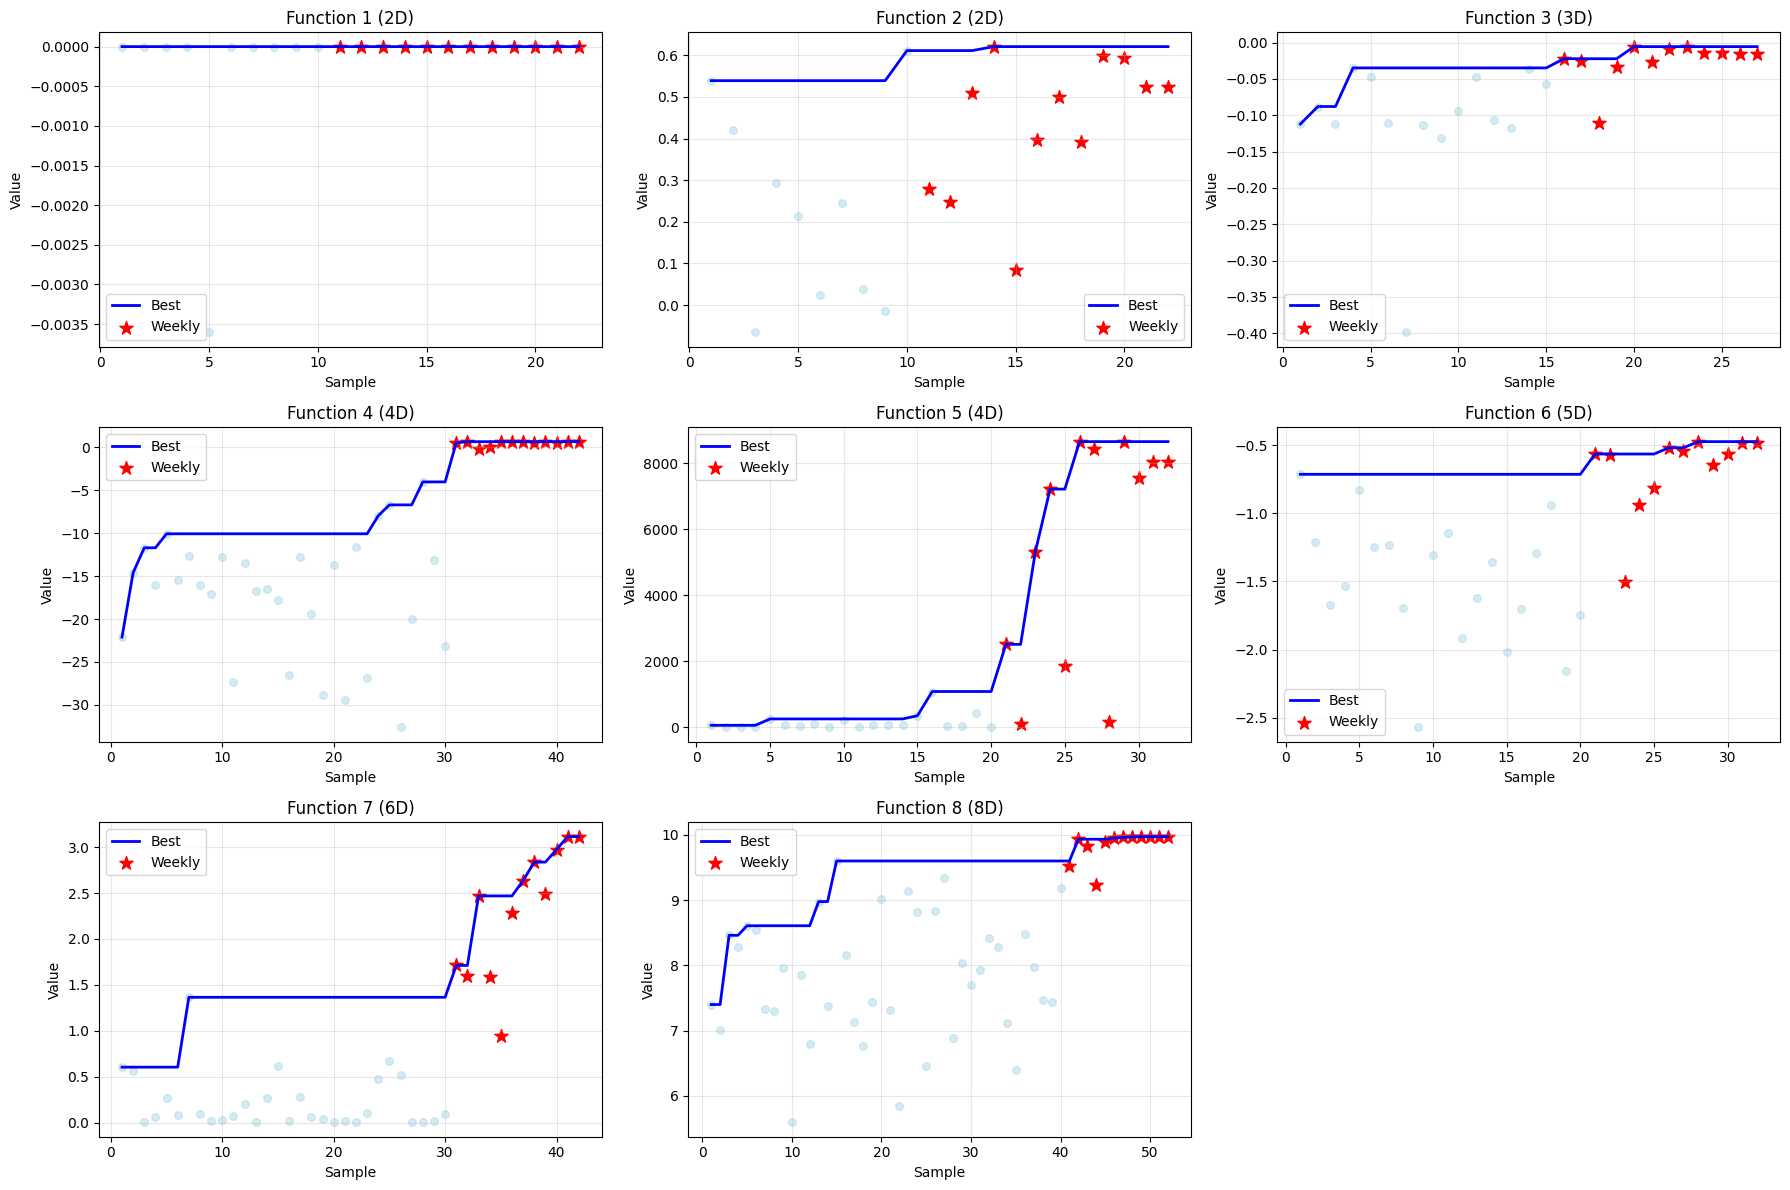

In [6]:
display_competition_summary(functions)
plot_progress(functions)

## 7. Manual single-function update (optional)

If you need to update one function by hand (e.g. corrected value):

In [8]:
# update_function_with_result(functions, func_id=1, x=np.array([0.5, 0.5]), y=1.23, week=4, save=True)